# German Credit Data

This notebook analyses the London Property Listing dataset

- https://www.kaggle.com/datasets/kabure/german-credit-data-with-risk

### Steps:
- Step 1: Load Data
- Step 2: First 5 rows
- Step 3: Plot Data
- Step 4: Prepare for Modelling
- Step 5: Modeling

### Models

- XGBoost
- LightGBM
- CatBoost
- Random Forest
- Logistic Regression
- Naive Bayes
- K-Nearest Neighbours
- Support Vector Machine
- Neural Network (Multilayer Perceptron)
- Linear Discriminant Analysis

### Results

| Model | Gini  |
|-------|-------|
| lda   | 0.57  |
| rf    | 0.56  |
| lr    | 0.56  |
| cat   | 0.55  |
| lgb   | 0.46  |
| nb    | 0.45  |
| xgb   | 0.44  |
| nn    | 0.38  |
| svc   | 0.13  |
| knn   | 0.12  |

# Step 0: Imports

In [1]:
#============================================
# Imports

#--------------------
# General
import pandas as pd
import numpy as np
import copy
pd.set_option('display.max_columns', 10000)
pd.set_option('display.max_rows', 10000)
pd.options.display.float_format = '{:,.2f}'.format
#--------------------

#--------------------
# Seaborn
import seaborn as sns
import matplotlib.pyplot as plt
#--------------------

#--------------------
# Models

# XGBoost
from xgboost import XGBClassifier

# LightGBM
from lightgbm import LGBMClassifier

# Random Forrest
from sklearn.ensemble import RandomForestClassifier

# Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Support Vector Machine
from sklearn.svm import SVC

# K-Nearest Neighbours
from sklearn.neighbors import KNeighborsClassifier

# Nerual Network
from sklearn.neural_network import MLPClassifier

# CATBoost
from catboost import CatBoostClassifier  

# Logistic REgression 
from sklearn.linear_model import LogisticRegression

# Linear Discriminant Analysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
#--------------------

#--------------------
# SHAP Explainability
import shap
shap.initjs()
#--------------------

#--------------------
# Model Performance
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
#--------------------

#--------------------
# Gini by split
def gini_group(y_true=None, y_score=None, group=None, round=2):
    """
    Calculate Gini for each group
    """
    levels=group.unique()
    values=[]
    for this_level in levels:
        this_y_true=y_true[group==this_level]
        this_y_score=y_score[group==this_level]
        values.append(roc_auc_score(y_true=this_y_true, y_score=this_y_score)*2-1)
    return pd.DataFrame({'group':levels, 'Gini':values}).round(round)
#--------------------

#--------------------
# ROC Curve
def roc_curve_group(y_true=None, y_score=None, group=None, round=2):
    """
    Calculate ROC Curve for each group
    """
    levels=group.unique()
    prep_auc=pd.DataFrame()
    for this_level in levels:
        this_y_true=y_true[group==this_level]
        this_y_score=y_score[group==this_level]
        fpr, tpr, _= roc_curve(y_true=this_y_true, y_score=this_y_score)
        t1=pd.DataFrame({'Model': this_level, 'fpr': fpr, 'tpr': tpr})
        prep_auc=pd.concat([prep_auc, t1], axis=0)
    return prep_auc.round(round)
#--------------------
#============================================

# Step 1: Load Data

In [2]:
#============================================
# Load Data
df=pd.read_csv('german_credit_data.csv')
df.columns = df.columns.str.replace(' ', '_')

# Rename featues
rename_dct = {
    'laufkont' : 'status',
    'laufzeit' : 'duration',
    'moral' : 'credit_history',
    'verw' : 'purpose',
    'hoehe' : 'amount',
    'sparkont' : 'savings',
    'beszeit' : 'employment_duration',
    'rate' : 'installment_rate',
    'famges' : 'personal_status_sex',
    'buerge' : 'other_debtors',
    'wohnzeit' : 'present_residence',
    'verm' : 'property',
    'alter' : 'age',
    'weitkred' : 'other_installment_plans',
    'wohn' : 'housing',
    'bishkred' : 'number_credits',
    'beruf' : 'job',
    'pers' : 'people_liable',
    'telef' : 'telephone',
    'gastarb' : 'foreign_worker',
    'kredit' : 'credit_risk'
}
df = df.rename(columns=rename_dct)

# Map features
map_status={
1 : 'no_checking_account',
2 : '_-inf_ 0_',
3 : '_0_ 200_',
4 : '_200_ inf_'}

map_credit_history={
0 : 'past delays',
1 : 'critical account',
2 : 'no credits',
3 : 'paid until now',
4 : 'paid this bank'}

map_purpose={
0 : 'others',
1 : 'car_new_',
2 : 'car_used_',
3 : 'furniture_equipment',
4 : 'radio_television',
5 : 'domestic appliances',
6 : 'repairs',
7 : 'education',
8 : 'vacation',
9 : 'retraining',
10 : 'business'}

map_savings={
1 : 'unknown/no_account',
2 : '_-inf_100_',
3 : '_100_500_',
4 : '_500_1000_',
5 : '_1000_inf_'}

map_employment_duration={
1 : 'unemp',
2 : '_0_1_',
3 : '_1_4_',
4 : '_4_7_',
5 : '_7_inf_'}

map_installment_rate={
1 : '_35_inf_',
2 : '_25_35_',
3 : '_20_25_',
4 : '_-inf_20_'}

map_personal_status_sex={
1 : 'male_divorcedseparated',
2 : 'femalenonsingle_or_malesingle',
3 : 'male_marriedwidowed',
4 : 'female_single'}

map_other_debtors={
1 : 'none',
2 : 'coapplicant',
3 : 'guarantor'}

map_present_residence={
1 : '_0_1_',
2 : '_1_4_',
3 : '_4_7_',
4 : '_7_inf_'}

map_property={
1 : 'unk_noproperty',
2 : 'car_or_other',
3 : 'savings_lifeins',
4 : 'realestate'}

map_other_installment_plans={
1 : 'bank',
2 : 'stores',
3 : 'none'}

map_housing={
1 : 'forfree',
2 : 'rent',
3 : 'own'}

map_number_credits={
1 : '_0_1_',
2 : '_2_3_',
3 : '_4_5_',
4 : '_6_inf_'}

map_job={
1 : 'unemp_unskill_nonres',
2 : 'unskilled_resident',
3 : 'skilledemp_official',
4 : 'high_quual_emp'}

map_people_liable={
1 : '_3_inf_',
2 : '_0_2_'}

map_telephone={
1 : 'no',
2 : 'yes'}

map_foreign_worker={
1 : 'yes',
2 : 'no'}

df['status']                  = df['status'].map(map_status)
df['credit_history']          = df['credit_history'].map(map_credit_history)
df['purpose']                 = df['purpose'].map(map_purpose)
df['savings']                 = df['savings'].map(map_savings)
df['employment_duration']     = df['employment_duration'].map(map_employment_duration)
df['installment_rate']        = df['installment_rate'].map(map_installment_rate)
df['personal_status_sex']     = df['personal_status_sex'].map(map_personal_status_sex)
df['other_debtors']           = df['other_debtors'].map(map_other_debtors)
df['present_residence']       = df['present_residence'].map(map_present_residence)
df['property']                = df['property'].map(map_property)
df['other_installment_plans'] = df['other_installment_plans'].map(map_other_installment_plans)
df['housing']                 = df['housing'].map(map_housing)
df['number_credits']          = df['number_credits'].map(map_number_credits)
df['job']                     = df['job'].map(map_job)
df['people_liable']           = df['people_liable'].map(map_people_liable)
df['telephone']               = df['telephone'].map(map_telephone)
df['foreign_worker']          = df['foreign_worker'].map(map_foreign_worker)

# Bad Flag
df['bad_flag'] = 1-df['credit_risk']
df.drop(columns=['credit_risk'], inplace=True)

print('--------------------')
print('## Information ##')
df.info()
print('--------------------')
print('')
#============================================

--------------------
## Information ##
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status                   1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   amount                   1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment_duration      1000 non-null   object
 7   installment_rate         1000 non-null   object
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  present_residence        1000 non-null   object
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  ho

# Step 2: First 5 rows

In [3]:
#============================================
# First 5 rows
print('--------------------')
print('## First 5 rows ##')
print(df.head(5))
print('--------------------')
#============================================

--------------------
## First 5 rows ##
                status  duration  credit_history     purpose  amount  \
0  no_checking_account        18  paid this bank   car_used_    1049   
1  no_checking_account         9  paid this bank      others    2799   
2            _-inf_ 0_        12      no credits  retraining     841   
3  no_checking_account        12  paid this bank      others    2122   
4  no_checking_account        12  paid this bank      others    2171   

              savings employment_duration installment_rate  \
0  unknown/no_account               _0_1_        _-inf_20_   
1  unknown/no_account               _1_4_          _25_35_   
2          _-inf_100_               _4_7_          _25_35_   
3  unknown/no_account               _1_4_          _20_25_   
4  unknown/no_account               _1_4_        _-inf_20_   

             personal_status_sex other_debtors present_residence  \
0  femalenonsingle_or_malesingle          none           _7_inf_   
1            male_

# Step 3: Plot Data

### Response ['bad_flag']

There are 1000 examples, 700 goods and 300 bads.

### Numerical Features 

['duration', 'amount', 'age']

### Categorical Featues 

['status', 'credit_history', 'purpose', 'savings', 
       'employment_duration',
       'installment_rate', 'personal_status_sex', 'other_debtors',
       'present_residence', 'property', 'other_installment_plans', 'housing',
       'number_credits', 'job', 'people_liable', 'telephone',
       'foreign_worker']

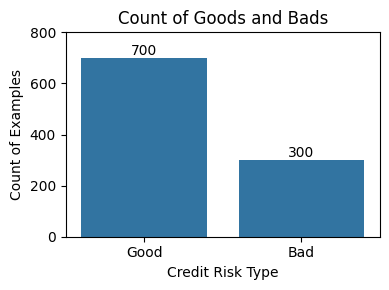

In [6]:
#============================================
# Plot Response

# Summarise for the plot
df_smry=df['bad_flag'].value_counts().reset_index()
df_smry['bad_flag']=df_smry['bad_flag'].map({0:'Good', 1:'Bad'})

# Response plot
plt.figure(figsize=(4,3))
ax=sns.barplot(df_smry, x='bad_flag', y='count')
ax.bar_label(ax.containers[0])
ax.set_xlabel('Credit Risk Type')
ax.set_ylabel('Count of Examples')
plt.ylim(0, 800) 
plt.title('Count of Goods and Bads')
plt.tight_layout()
plt.savefig("credit-data-count-goods-bads.png", dpi=300)
plt.show()
#============================================

C:\Users\markt\AppData\Local\Temp\ipykernel_18984\2376117698.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


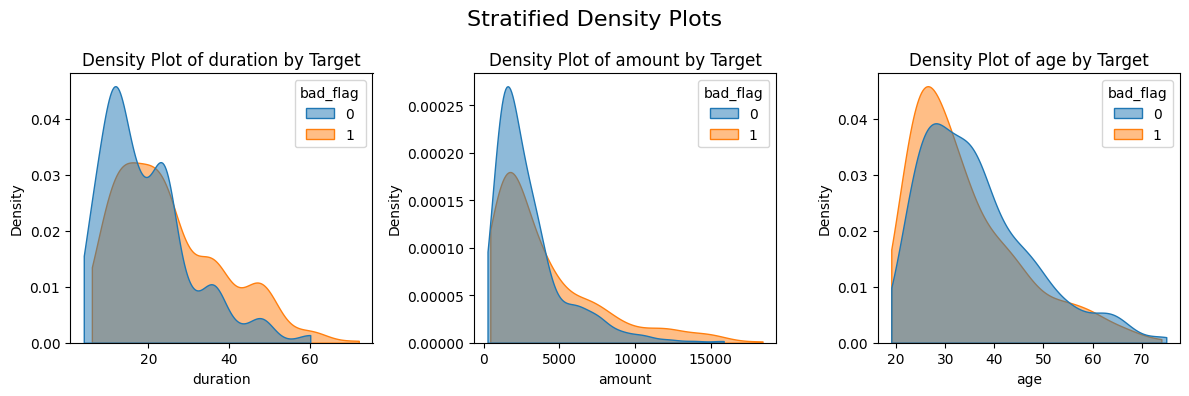

In [ ]:
#============================================
# Plot Numeric Features

# Numeric Features
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('bad_flag')
num_numeric_cols=len(numeric_cols)

# KDE Plots
fig, axes = plt.subplots(1, num_numeric_cols, figsize=(12, 4), constrained_layout=True)
for i, this_var in enumerate(numeric_cols):
    sns.kdeplot(data=df, 
                x=this_var, 
                hue='bad_flag', 
                fill=True, 
                common_norm=False,
                cut=0,
                alpha=0.5,
                ax=axes[i])
    axes[i].set_title(f'Density Plot of {this_var} by Target', fontsize=12)
fig.suptitle('Stratified Density Plots', fontsize=16)
plt.tight_layout()
plt.savefig("credit-data-numeric-features.png", dpi=300)
plt.show()
#============================================

# Insights from Stratified KDE Plots

The stratified KDE (Kernel Density Estimate) plots provide insights into the distribution of numerical features(`duration`, `amount`, `age`) stratified by the target variable (`bad_flag`). Here are the key observations:

## 1. Duration
- The distribution of `duration` for both good and bad credit risks shows that longer durations are more common among bad credit risks.
- There is a noticeable peak for bad credit risks at higher durations, indicating that longer loan durations might be associated with higher credit risk.

## 2. Amount
- The distribution of `amount` for both good and bad credit risks shows that higher loan amounts are more common among bad credit risks.
- There is a noticeable peak for bad credit risks at higher loan amounts, suggesting that larger loan amounts might be associated with higher credit risk.

## 3. Age
- The distribution of `age` for both good and bad credit risks shows that younger individuals are more common among bad credit risks.
- There is a noticeable peak for bad credit risks at lower ages, indicating that younger age might be associated with higher credit risk.

---

Overall, the stratified KDE plots suggest that longer loan durations, higher loan amounts, and younger ages are associated with higher credit risk. These insights can be useful for understanding the characteristics of high-risk loans and individuals.


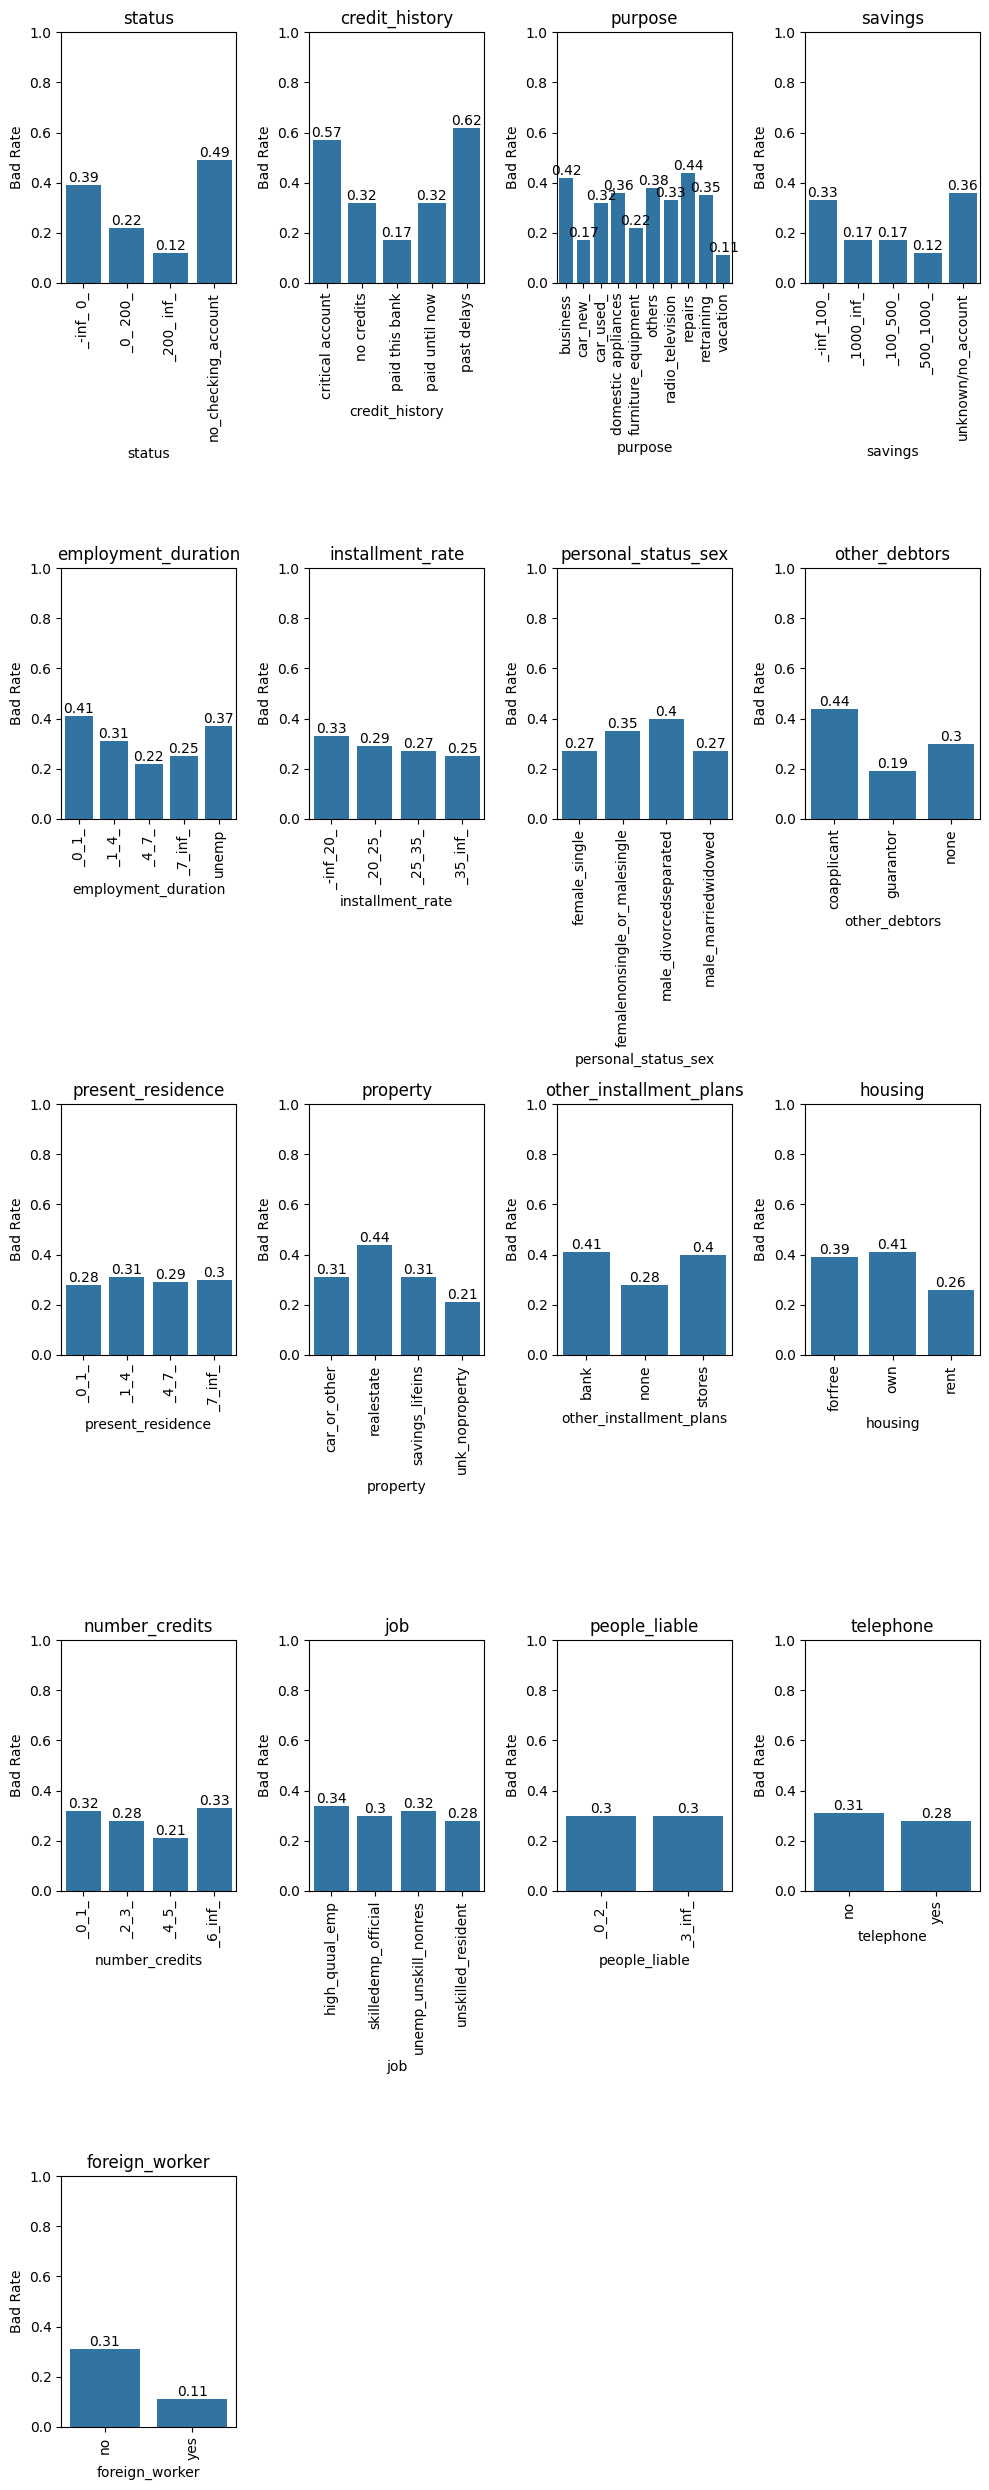

In [16]:
#============================================
# Plot Categorical Features

# Identify categorical columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns
num_categorical_cols = len(categorical_cols)

# Set up grid dimensions
cols = 4
rows = (num_categorical_cols + cols - 1) // cols  # Calculate required rows

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(10, 5 * rows))
axes = axes.flatten()  # Flatten to make indexing easier

# Loop over categorical columns
for i, col in enumerate(categorical_cols):
    df_smry = df[['bad_flag', col]].groupby(col).mean().reset_index().round(2)

    ax = axes[i]  # Get the current axis
    sns.barplot(data=df_smry, x=col, y='bad_flag', ax=ax)
    ax.bar_label(ax.containers[0])
    ax.set_xlabel(col)
    ax.set_ylabel('Bad Rate')
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylim(0, 1)
    #ax.set_title(f'Bad Rate by {col}')
    ax.set_title(f'{col}')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("credit-data-categorical-features.png", dpi=300)
plt.show()
#============================================

In [1]:
df

NameError: name 'df' is not defined

# Step 4: Prepare for Modelling

Undertake the following:

- one-hot dummy encoding of categorical featuers
- train-test split

In [17]:
# One-Hot Encoding
df2=copy.deepcopy(pd.get_dummies(df,dtype=int))
df2.columns=df2.columns.str.replace('-', '_').str.replace(' ', '_')

# X and y
X=df2.drop(['bad_flag'], axis=1)
y=df2['bad_flag']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Modeling

- XGBoost
- LightGBM
- CatBoost
- Random Forest
- Logistic Regression
- Naive Bayes
- K-Nearest Neighbours
- Support Vector Machine
- Neural Network (Multilayer Perceptron)
- Linear Discriminant Analysis

In [18]:
#--------------------
# XGBoost
model_xgb = XGBClassifier()
model_xgb.fit(X_train, y_train)
pred_xgb=pd.DataFrame({'model': 'xgb', 'target': y_test, 'pred': model_xgb.predict_proba(X_test)[:,1]})
#--------------------

In [19]:
#--------------------
# Light GBM
model_lgb=LGBMClassifier(verbose=-1)
model_lgb.fit(X_train, y_train)
pred_lgb=pd.DataFrame({'model': 'lgb', 'target': y_test, 'pred': model_lgb.predict_proba(X_test)[:,1]})
#--------------------

In [20]:
#--------------------
# Catboost
model_cat=CatBoostClassifier(verbose=False)
model_cat.fit(X_train, y_train)
pred_cat=pd.DataFrame({'model': 'cat', 'target': y_test, 'pred': model_cat.predict_proba(X_test)[:,1]})
#--------------------

In [22]:
#--------------------
# Random Forrest
model_rfc=RandomForestClassifier()
model_rfc.fit(X_train, y_train)
pred_rfc=pd.DataFrame({'model': 'rf', 'target': y_test, 'pred': model_rfc.predict_proba(X_test)[:,1]})
#--------------------

In [23]:
#--------------------
# Logistic Regression
model_lrg=LogisticRegression(penalty=None, solver='newton-cg')
model_lrg.fit(X_train, y_train)
pred_lrg=pd.DataFrame({'model': 'lr', 'target': y_test, 'pred': model_lrg.predict_proba(X_test)[:,1]})
#--------------------

In [24]:
#--------------------
# Naive Bayes
model_nb=GaussianNB()
model_nb.fit(X_train,  y_train)
pred_nb=pd.DataFrame({'model': 'nb', 'target': y_test, 'pred': model_nb.predict_proba(X_test)[:,1]})
#--------------------

In [25]:
#--------------------
# K-Nearest Neighbours
model_knn=KNeighborsClassifier()
model_knn.fit(X_train, y_train)
pred_knn=pd.DataFrame({'model': 'knn', 'target': y_test, 'pred': model_knn.predict_proba(X_test)[:,1]})
#--------------------

In [26]:
#--------------------
# Support Vector Machine
model_svc=SVC(probability=True)
model_svc.fit(X_train, y_train)
pred_svc=pd.DataFrame({'model': 'svc', 'target': y_test, 'pred': model_svc.predict_proba(X_test)[:,1]})
#--------------------

In [27]:
#--------------------
# Neural Network - Multilayer Perception
model_mlp=MLPClassifier(hidden_layer_sizes=(10,), max_iter=2000)
model_mlp.fit(X_train, y_train)
pred_mlp=pd.DataFrame({'model': 'nn', 'target': y_test, 'pred': model_mlp.predict_proba(X_test)[:,1]})
#--------------------

In [28]:
#--------------------
# Linear Discriminant Analysis
model_lda=LinearDiscriminantAnalysis()
model_lda.fit(X_train, y_train)
pred_lda=pd.DataFrame({'model': 'lda', 'target': y_test, 'pred': model_lda.predict_proba(X_test)[:,1]})
#--------------------

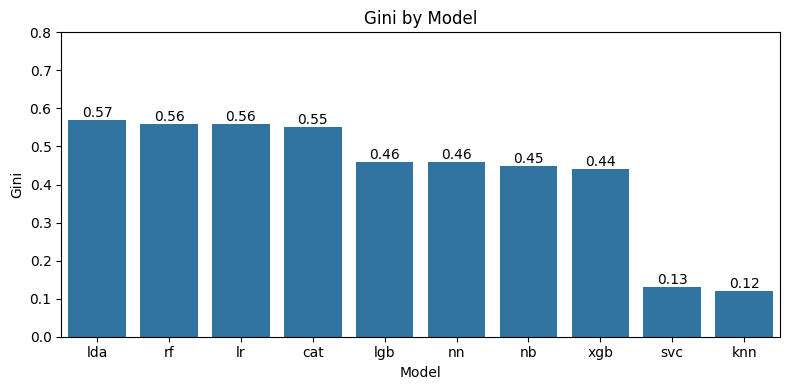

In [31]:
# Join all predictions
pred=pd.concat([pred_xgb, 
                pred_lgb, 
                pred_cat, 
                pred_rfc, 
                pred_lrg, 
                pred_nb, 
                pred_knn, 
                pred_svc, 
                pred_mlp, 
                pred_lda], axis=0).reset_index(drop=True)

# Gini
gini_df=gini_group(y_true=pred['target'], 
                   y_score=pred['pred'], 
                   group=pred['model'], 
                   round=2)\
                  .sort_values('Gini', ascending=False)\
                  .reset_index()

# ROC Curve
plt.figure(figsize=(8, 4))
ax=sns.barplot(data=gini_df, y='Gini', x='group')
ax.bar_label(ax.containers[0])
plt.ylabel('Gini')
plt.xlabel('Model')
plt.ylim(0, 0.8)
plt.title('Gini by Model')
plt.tight_layout()
plt.savefig("credit-data-gini.png", dpi=300)
plt.show()

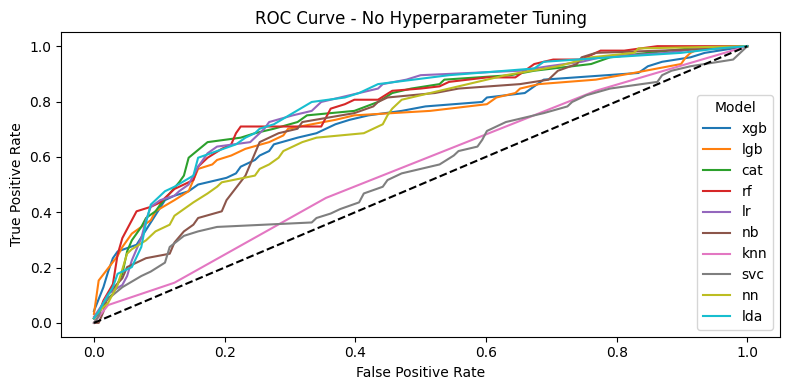

In [32]:
# ROC Curve
roc_curve_df=roc_curve_group(y_true=pred['target'], 
                             y_score=pred['pred'], 
                             group=pred['model'], 
                             round=6)

# Plot ROC Curve
plt.figure(figsize=(8, 4))
sns.lineplot(data=roc_curve_df, x='fpr', y='tpr', hue='Model', errorbar=None)
plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - No Hyperparameter Tuning')
plt.tight_layout()
plt.savefig("credit-data-roc-curve.png", dpi=300)
plt.show()